# 24 - Comparaciones IBERAMIA

Este notebook consolida los resultados de los modelos entrenados para el Mburicao:

- Persistencia;
- Ridge-ARX;
- Gradient Boosting-ARX;
- ARIMA;
- SARIMAX;
- N-BEATS;
- LSTM.

El objetivo es crear tablas comparativas y figuras exploratorias que sirvan como base para extraer conclusiones del paper. Este notebook **no reentrena modelos**. Solo importa reportes ya generados, estandariza nombres, construye tablas comparativas y genera visualizaciones.

## Principio metodologico de la comparacion

Los modelos no tienen todos la misma mecanica interna de entrenamiento, pero se comparan bajo un protocolo comun:

- mismos segmentos de test;
- mismos horizontes de prediccion: t+10, t+20 y t+30;
- mismas metricas;
- misma agregacion global 2021+2025;
- mismas condiciones criticas.

La comparacion se hace sobre las predicciones y metricas finales de test. Las tablas de este notebook estan pensadas para responder:

- que modelo tiene mejor desempeno global?
- que modelo conserva mejor desempeno a t+30?
- que modelo funciona mejor en lluvia, niveles altos y ascensos fuertes?
- que modelos subestiman o sobreestiman sistematicamente?
- cuanto se gana respecto a persistencia, Ridge-ARX y N-BEATS?

## Imports

In [14]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

## Configuracion

In [15]:
TIME_COL = "Time"
TARGET_COL = "Nivel"
RAIN_COL = "Precipitacion"

FORECAST_HORIZON = 3
LEAD_TO_PLOT = 30
EVENT_SEGMENT = "2025"
EVENT_SELECTION = "max_actual"  # opciones: max_actual, max_lluvia_1h
ZOOM_HOURS_BEFORE = 6
ZOOM_HOURS_AFTER = 12

MODEL_ORDER = [
    "Persistencia",
    "Ridge_ARX_local",
    "GradientBoosting_ARX",
    "ARIMA_selected",
    "SARIMAX_lagged_exog_selected",
    "NBEATS",
    "LSTM",
]

MODEL_LABELS = {
    "Persistencia": "Persistencia",
    "Ridge_ARX_local": "Ridge-ARX",
    "GradientBoosting_ARX": "Gradient Boosting-ARX",
    "ARIMA_selected": "ARIMA",
    "SARIMAX_lagged_exog_selected": "SARIMAX",
    "NBEATS": "N-BEATS",
    "LSTM": "LSTM",
}

MODEL_FAMILIES = {
    "Persistencia": "Baseline ingenuo",
    "Ridge_ARX_local": "ML lineal ARX",
    "GradientBoosting_ARX": "ML no lineal ARX",
    "ARIMA_selected": "Estadistico",
    "SARIMAX_lagged_exog_selected": "Estadistico con exogenas",
    "NBEATS": "Deep learning",
    "LSTM": "Deep learning recurrente",
}

MODEL_COLORS = {
    "Persistencia": "#7f7f7f",
    "Ridge_ARX_local": "#1f77b4",
    "GradientBoosting_ARX": "#2ca02c",
    "ARIMA_selected": "#9467bd",
    "SARIMAX_lagged_exog_selected": "#8c564b",
    "NBEATS": "#ff7f0e",
    "LSTM": "#d62728",
}

## Rutas

In [16]:
def resolve_project_dir():
    cwd = os.getcwd()
    candidates = [
        cwd,
        os.path.dirname(cwd),
        os.path.join(cwd, "Mburicao_Iberamia"),
        os.path.join(os.path.dirname(cwd), "Mburicao_Iberamia"),
        r"G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia",
        r"D:\Google Drive\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia",
        "/data/students/federico.moran",
        "/data/students/federico.moran/notebooks",
    ]

    for candidate in candidates:
        if not candidate:
            continue
        if os.path.exists(os.path.join(candidate, "notebooks")) or os.path.exists(os.path.join(candidate, "data")):
            return os.path.abspath(candidate)

    return os.path.abspath(cwd)


PROJECT_DIR = resolve_project_dir()
REPORTS_ROOT = os.path.join(PROJECT_DIR, "reports")
PRED_EXPORT_DIR = os.path.join(PROJECT_DIR, "predicciones_para_brasil")

REPORTS_DIR = os.path.join(REPORTS_ROOT, "24_comparaciones_Iberamia")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_DIR: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia
REPORTS_DIR: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia
FIGURES_DIR: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures


## Fuentes de metricas

In [17]:
METRIC_SOURCES = {
    "15_finales": {
        "global_segmento": os.path.join(REPORTS_ROOT, "15_finales", "15_metricas_global_segmento.csv"),
        "por_lead": os.path.join(REPORTS_ROOT, "15_finales", "15_metricas_por_lead.csv"),
        "condiciones": os.path.join(REPORTS_ROOT, "15_finales", "15_metricas_condiciones.csv"),
        "condiciones_por_lead": os.path.join(REPORTS_ROOT, "15_finales", "15_metricas_condiciones_por_lead.csv"),
        "models": ["Persistencia", "Ridge_ARX_local", "NBEATS"],
    },
    "23_gradient_boosting_arx": {
        "global_segmento": os.path.join(REPORTS_ROOT, "23_gradient_boosting_arx", "23_metricas_global_segmento.csv"),
        "por_lead": os.path.join(REPORTS_ROOT, "23_gradient_boosting_arx", "23_metricas_por_lead.csv"),
        "condiciones": os.path.join(REPORTS_ROOT, "23_gradient_boosting_arx", "23_metricas_condiciones.csv"),
        "condiciones_por_lead": os.path.join(REPORTS_ROOT, "23_gradient_boosting_arx", "23_metricas_condiciones_por_lead.csv"),
        "models": ["GradientBoosting_ARX"],
    },
    "17_arima_sarimax_baselines": {
        "global_segmento": os.path.join(REPORTS_ROOT, "17_arima_sarimax_baselines", "17_metricas_global_segmento.csv"),
        "por_lead": os.path.join(REPORTS_ROOT, "17_arima_sarimax_baselines", "17_metricas_por_lead.csv"),
        "condiciones": os.path.join(REPORTS_ROOT, "17_arima_sarimax_baselines", "17_metricas_condiciones.csv"),
        "condiciones_por_lead": os.path.join(REPORTS_ROOT, "17_arima_sarimax_baselines", "17_metricas_condiciones_por_lead.csv"),
        "models": ["ARIMA_selected", "SARIMAX_lagged_exog_selected"],
    },
    "22_lstm_vs_modelos": {
        "global_segmento": os.path.join(REPORTS_ROOT, "22_lstm_vs_modelos", "22_metricas_global_segmento.csv"),
        "por_lead": os.path.join(REPORTS_ROOT, "22_lstm_vs_modelos", "22_metricas_por_lead.csv"),
        "condiciones": os.path.join(REPORTS_ROOT, "22_lstm_vs_modelos", "22_metricas_condiciones.csv"),
        "condiciones_por_lead": os.path.join(REPORTS_ROOT, "22_lstm_vs_modelos", "22_metricas_condiciones_por_lead.csv"),
        "models": ["LSTM"],
    },
}


def standardize_model_columns(df, source_name):
    out = df.copy()
    out["modelo"] = out["modelo"].astype(str)
    out["segmento"] = out["segmento"].astype(str)
    out["modelo_label"] = out["modelo"].map(MODEL_LABELS).fillna(out["modelo"])
    out["familia"] = out["modelo"].map(MODEL_FAMILIES).fillna("Otro")
    out["source"] = source_name
    out["model_order"] = out["modelo"].map({model: idx for idx, model in enumerate(MODEL_ORDER)})
    return out


def load_metric_kind(kind):
    frames = []
    missing = []

    for source_name, spec in METRIC_SOURCES.items():
        path = spec[kind]
        if not os.path.exists(path):
            missing.append({"source": source_name, "kind": kind, "path": path})
            continue

        df = pd.read_csv(path)
        df = df[df["modelo"].isin(spec["models"])].copy()
        df = standardize_model_columns(df, source_name)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No se encontro ninguna tabla para {kind}")

    out = pd.concat(frames, axis=0, ignore_index=True)
    out = out.sort_values([col for col in ["segmento", "condicion", "lead_minutes", "model_order"] if col in out.columns]).reset_index(drop=True)
    return out, pd.DataFrame(missing)


metrics_global_segmento_df, missing_global = load_metric_kind("global_segmento")
metrics_lead_df, missing_lead = load_metric_kind("por_lead")
metrics_conditions_df, missing_conditions = load_metric_kind("condiciones")
metrics_conditions_lead_df, missing_conditions_lead = load_metric_kind("condiciones_por_lead")

missing_tables_df = pd.concat(
    [missing_global, missing_lead, missing_conditions, missing_conditions_lead],
    axis=0,
    ignore_index=True,
)

display(metrics_global_segmento_df)
if len(missing_tables_df):
    display(missing_tables_df)

,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order
0,Persistencia,2021,18993,0.012850,0.090860,0.825797,3.587244,3.713976,-0.000011,0.825797,Persistencia,Baseline ingenuo,15_finales,0
1,Ridge_ARX_local,2021,18993,0.010978,0.062659,0.917151,4.331058,4.231989,0.003495,0.917151,Ridge-ARX,ML lineal ARX,15_finales,1
2,GradientBoosting_ARX,2021,18993,0.013060,0.082957,0.854783,4.408994,4.408721,-0.002391,0.854783,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2
3,ARIMA_selected,2021,18993,0.012738,0.079241,0.867502,4.390913,4.595826,-0.005443,0.867502,ARIMA,Estadistico,17_arima_sarimax_baselines,3
4,SARIMAX_lagged_exog_selected,2021,18993,0.012766,0.075049,0.881148,4.442307,4.636119,-0.005224,0.881148,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4
5,NBEATS,2021,18993,0.026913,0.070092,0.896332,20.611016,22.596037,-0.002065,0.896332,N-BEATS,Deep learning,15_finales,5
6,LSTM,2021,18993,0.011680,0.055375,0.935293,5.186281,5.001186,0.000391,0.935293,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6
7,Persistencia,2025,13071,0.013926,0.094703,0.806441,1.070662,1.127978,-0.000028,0.806441,Persistencia,Baseline ingenuo,15_finales,0
8,Ridge_ARX_local,2025,13071,0.015719,0.078306,0.867665,1.711449,1.729543,-0.003786,0.867665,Ridge-ARX,ML lineal ARX,15_finales,1
9,GradientBoosting_ARX,2025,13071,0.019259,0.082860,0.851823,2.266286,2.365964,-0.017226,0.851823,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2


## Tablas comparativas completas

In [18]:
def save_table(df, filename):
    path = os.path.join(REPORTS_DIR, filename)
    df.to_csv(path, index=False)
    print("Guardado:", path)
    return path


save_table(metrics_global_segmento_df, "24_metricas_global_segmento_comparativas.csv")
save_table(metrics_lead_df, "24_metricas_por_lead_comparativas.csv")
save_table(metrics_conditions_df, "24_metricas_condiciones_comparativas.csv")
save_table(metrics_conditions_lead_df, "24_metricas_condiciones_por_lead_comparativas.csv")

global_only_df = metrics_global_segmento_df[metrics_global_segmento_df["segmento"] == "global"].copy()
global_only_df = global_only_df.sort_values(["RMSE", "model_order"]).reset_index(drop=True)

t30_global_df = metrics_lead_df[
    (metrics_lead_df["segmento"] == "global")
    & (metrics_lead_df["lead_minutes"] == 30)
].copy().sort_values(["RMSE", "model_order"]).reset_index(drop=True)

conditions_t30_global_df = metrics_conditions_lead_df[
    (metrics_conditions_lead_df["segmento"] == "global")
    & (metrics_conditions_lead_df["lead_minutes"] == 30)
].copy().sort_values(["condicion", "RMSE", "model_order"]).reset_index(drop=True)

# En el notebook 15, la tabla global por condicion a t+30 se guarda como
# tabla final. Se usa como respaldo para incluir Persistencia, Ridge-ARX y
# N-BEATS cuando esas filas no estan en el CSV largo por lead.
conditions_t30_fallback_path = os.path.join(REPORTS_ROOT, "15_finales", "15_tabla_condiciones_t30.csv")
if os.path.exists(conditions_t30_fallback_path):
    conditions_t30_fallback_df = pd.read_csv(conditions_t30_fallback_path)
    conditions_t30_fallback_df = conditions_t30_fallback_df[
        conditions_t30_fallback_df["modelo"].isin(["Persistencia", "Ridge_ARX_local", "NBEATS"])
    ].copy()
    conditions_t30_fallback_df["segmento"] = conditions_t30_fallback_df["segmento"].astype(str)
    conditions_t30_fallback_df = conditions_t30_fallback_df[
        (conditions_t30_fallback_df["segmento"] == "global")
        & (conditions_t30_fallback_df["lead_minutes"] == 30)
    ].copy()

    if not conditions_t30_fallback_df.empty:
        conditions_t30_fallback_df = standardize_model_columns(
            conditions_t30_fallback_df,
            "15_finales",
        )
        conditions_t30_global_df = pd.concat(
            [conditions_t30_global_df, conditions_t30_fallback_df],
            ignore_index=True,
        )
        conditions_t30_global_df = (
            conditions_t30_global_df
            .drop_duplicates(
                subset=["modelo", "segmento", "condicion", "lead_minutes"],
                keep="last",
            )
            .sort_values(["condicion", "RMSE", "model_order"])
            .reset_index(drop=True)
        )

save_table(global_only_df, "24_tabla_global.csv")
save_table(t30_global_df, "24_tabla_t30_global.csv")
save_table(conditions_t30_global_df, "24_tabla_condiciones_t30_global.csv")

display(global_only_df)
display(t30_global_df)
display(conditions_t30_global_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_global_segmento_comparativas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_por_lead_comparativas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_condiciones_comparativas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_condiciones_por_lead_comparativas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_global.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_t30_global.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_condiciones_t30_global.csv


,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order
0,LSTM,global,32064,0.011567,0.061245,0.958620,3.555974,3.445326,-0.000897,0.958620,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6
1,Ridge_ARX_local,global,32064,0.012911,0.069465,0.946767,3.263166,3.211858,0.000527,0.946767,Ridge-ARX,ML lineal ARX,15_finales,1
2,SARIMAX_lagged_exog_selected,global,32064,0.013406,0.077836,0.933163,3.227299,3.368502,-0.005370,0.933163,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4
3,NBEATS,global,32064,0.027840,0.079620,0.930065,13.915910,15.076323,-0.002179,0.930065,N-BEATS,Deep learning,15_finales,5
4,ARIMA_selected,global,32064,0.013997,0.082739,0.924478,3.308174,3.470145,-0.007279,0.924478,ARIMA,Estadistico,17_arima_sarimax_baselines,3
5,GradientBoosting_ARX,global,32064,0.015587,0.082917,0.924152,3.535511,3.575984,-0.008438,0.924152,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2
6,Persistencia,global,32064,0.013288,0.092446,0.905719,2.561350,2.659785,-0.000018,0.905719,Persistencia,Baseline ingenuo,15_finales,0


,modelo,segmento,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order
0,LSTM,global,30,10688,0.016052,0.077489,0.933758,5.075717,4.921755,-0.003500,0.933758,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6
1,Ridge_ARX_local,global,30,10688,0.018887,0.092061,0.906503,4.621110,4.511246,0.000659,0.906503,Ridge-ARX,ML lineal ARX,15_finales,1
2,NBEATS,global,30,10688,0.017606,0.093899,0.902731,4.587694,4.448885,-0.000975,0.902731,N-BEATS,Deep learning,15_finales,5
3,GradientBoosting_ARX,global,30,10688,0.019653,0.097683,0.894733,4.470140,4.531591,-0.011481,0.894733,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2
4,SARIMAX_lagged_exog_selected,global,30,10688,0.019716,0.104621,0.879249,4.483905,4.721805,-0.008174,0.879249,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4
5,ARIMA_selected,global,30,10688,0.021119,0.110774,0.864630,4.716272,4.988860,-0.011683,0.864630,ARIMA,Estadistico,17_arima_sarimax_baselines,3
6,Persistencia,global,30,10688,0.019103,0.121584,0.836920,3.488117,3.617801,-0.000027,0.836920,Persistencia,Baseline ingenuo,15_finales,0


,modelo,segmento,condicion,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order
0,LSTM,global,delta_positivo_alto,30,265,0.204772,0.404597,0.696596,20.263246,22.003833,-0.126647,0.696596,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6
1,Ridge_ARX_local,global,delta_positivo_alto,30,265,0.209790,0.407063,0.692886,21.277832,25.260679,-0.155336,0.692886,Ridge-ARX,ML lineal ARX,15_finales,1
2,NBEATS,global,delta_positivo_alto,30,265,0.238867,0.485764,0.562652,23.360253,24.805684,-0.136582,0.562652,N-BEATS,Deep learning,15_finales,5
3,GradientBoosting_ARX,global,delta_positivo_alto,30,265,0.250507,0.504576,0.528124,22.108291,26.265612,-0.203213,0.528124,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2
4,SARIMAX_lagged_exog_selected,global,delta_positivo_alto,30,265,0.277854,0.558904,0.421038,24.743996,33.707828,-0.274120,0.421038,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4
5,Persistencia,global,delta_positivo_alto,30,265,0.282373,0.591917,0.350622,24.015595,33.486699,-0.281488,0.350622,Persistencia,Baseline ingenuo,15_finales,0
6,ARIMA_selected,global,delta_positivo_alto,30,265,0.296859,0.593115,0.347992,26.187943,36.109696,-0.296859,0.347992,ARIMA,Estadistico,17_arima_sarimax_baselines,3
7,LSTM,global,lluvia_1h_alta,30,141,0.409628,0.586691,0.676434,34.613074,33.470564,-0.188762,0.676434,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6
8,Ridge_ARX_local,global,lluvia_1h_alta,30,141,0.464937,0.650283,0.602490,34.620493,35.262121,-0.091340,0.602490,Ridge-ARX,ML lineal ARX,15_finales,1
9,NBEATS,global,lluvia_1h_alta,30,141,0.507947,0.726859,0.503358,40.093365,38.772035,-0.275527,0.503358,N-BEATS,Deep learning,15_finales,5


## Mejoras relativas respecto a referencias

In [19]:
def add_reference_deltas(df, group_cols, reference_models):
    out = df.copy()

    for ref_model in reference_models:
        label = MODEL_LABELS.get(ref_model, ref_model).replace("-", "_").replace(" ", "_")
        out[f"mejora_RMSE_vs_{label}_%"] = np.nan
        out[f"delta_NSE_vs_{label}"] = np.nan
        out[f"delta_MAE_vs_{label}"] = np.nan

    if group_cols:
        grouped = out.groupby(group_cols, dropna=False).groups.items()
    else:
        grouped = [(None, out.index)]

    for _, idx in grouped:
        sub = out.loc[idx]
        for ref_model in reference_models:
            ref_rows = sub[sub["modelo"] == ref_model]
            if ref_rows.empty:
                continue

            ref = ref_rows.iloc[0]
            label = MODEL_LABELS.get(ref_model, ref_model).replace("-", "_").replace(" ", "_")
            ref_rmse = float(ref["RMSE"])
            ref_nse = float(ref["NSE"])
            ref_mae = float(ref["MAE"])

            if abs(ref_rmse) > 1e-12:
                out.loc[idx, f"mejora_RMSE_vs_{label}_%"] = (ref_rmse - out.loc[idx, "RMSE"]) / ref_rmse * 100
            out.loc[idx, f"delta_NSE_vs_{label}"] = out.loc[idx, "NSE"] - ref_nse
            out.loc[idx, f"delta_MAE_vs_{label}"] = out.loc[idx, "MAE"] - ref_mae

    return out


reference_models = ["Persistencia", "Ridge_ARX_local", "NBEATS"]

global_with_deltas_df = add_reference_deltas(global_only_df, group_cols=None, reference_models=reference_models)
t30_with_deltas_df = add_reference_deltas(t30_global_df, group_cols=None, reference_models=reference_models)
conditions_t30_with_deltas_df = add_reference_deltas(
    conditions_t30_global_df,
    group_cols=["condicion"],
    reference_models=reference_models,
)

save_table(global_with_deltas_df, "24_tabla_global_con_deltas.csv")
save_table(t30_with_deltas_df, "24_tabla_t30_global_con_deltas.csv")
save_table(conditions_t30_with_deltas_df, "24_tabla_condiciones_t30_global_con_deltas.csv")

display(global_with_deltas_df)
display(t30_with_deltas_df)
display(conditions_t30_with_deltas_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_global_con_deltas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_t30_global_con_deltas.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_tabla_condiciones_t30_global_con_deltas.csv


,modelo,segmento,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order,mejora_RMSE_vs_Persistencia_%,delta_NSE_vs_Persistencia,delta_MAE_vs_Persistencia,mejora_RMSE_vs_Ridge_ARX_%,delta_NSE_vs_Ridge_ARX,delta_MAE_vs_Ridge_ARX,mejora_RMSE_vs_N_BEATS_%,delta_NSE_vs_N_BEATS,delta_MAE_vs_N_BEATS
0,LSTM,global,32064,0.011567,0.061245,0.958620,3.555974,3.445326,-0.000897,0.958620,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6,33.750307,0.052901,-0.001722,11.832936,0.011853,-0.001344,23.078073,0.028555,-0.016274
1,Ridge_ARX_local,global,32064,0.012911,0.069465,0.946767,3.263166,3.211858,0.000527,0.946767,Ridge-ARX,ML lineal ARX,15_finales,1,24.858911,0.041048,-0.000378,0.000000,0.000000,0.000000,12.754352,0.016702,-0.014929
2,SARIMAX_lagged_exog_selected,global,32064,0.013406,0.077836,0.933163,3.227299,3.368502,-0.005370,0.933163,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4,15.803076,0.027444,0.000118,-12.051775,-0.013604,0.000496,2.239703,0.003098,-0.014434
3,NBEATS,global,32064,0.027840,0.079620,0.930065,13.915910,15.076323,-0.002179,0.930065,N-BEATS,Deep learning,15_finales,5,13.874112,0.024347,0.014552,-14.618897,-0.016702,0.014929,0.000000,0.000000,0.000000
4,ARIMA_selected,global,32064,0.013997,0.082739,0.924478,3.308174,3.470145,-0.007279,0.924478,ARIMA,Estadistico,17_arima_sarimax_baselines,3,10.500128,0.018760,0.000709,-19.109096,-0.022289,0.001087,-3.917503,-0.005587,-0.013843
5,GradientBoosting_ARX,global,32064,0.015587,0.082917,0.924152,3.535511,3.575984,-0.008438,0.924152,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2,10.306681,0.018433,0.002299,-19.366540,-0.022615,0.002677,-4.142112,-0.005914,-0.012253
6,Persistencia,global,32064,0.013288,0.092446,0.905719,2.561350,2.659785,-0.000018,0.905719,Persistencia,Baseline ingenuo,15_finales,0,0.000000,0.000000,0.000000,-33.082979,-0.041048,0.000378,-16.109108,-0.024347,-0.014552


,modelo,segmento,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order,mejora_RMSE_vs_Persistencia_%,delta_NSE_vs_Persistencia,delta_MAE_vs_Persistencia,mejora_RMSE_vs_Ridge_ARX_%,delta_NSE_vs_Ridge_ARX,delta_MAE_vs_Ridge_ARX,mejora_RMSE_vs_N_BEATS_%,delta_NSE_vs_N_BEATS,delta_MAE_vs_N_BEATS
0,LSTM,global,30,10688,0.016052,0.077489,0.933758,5.075717,4.921755,-0.003500,0.933758,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6,36.266674,0.096838,-0.003052,15.828059,0.027255,-0.002835,17.476081,0.031027,-0.001554
1,Ridge_ARX_local,global,30,10688,0.018887,0.092061,0.906503,4.621110,4.511246,0.000659,0.906503,Ridge-ARX,ML lineal ARX,15_finales,1,24.281981,0.069583,-0.000216,0.000000,0.000000,0.000000,1.957923,0.003772,0.001281
2,NBEATS,global,30,10688,0.017606,0.093899,0.902731,4.587694,4.448885,-0.000975,0.902731,N-BEATS,Deep learning,15_finales,5,22.769874,0.065811,-0.001497,-1.997023,-0.003772,-0.001281,0.000000,0.000000,0.000000
3,GradientBoosting_ARX,global,30,10688,0.019653,0.097683,0.894733,4.470140,4.531591,-0.011481,0.894733,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2,19.657550,0.057813,0.000550,-6.107438,-0.011769,0.000766,-4.029936,-0.007998,0.002047
4,SARIMAX_lagged_exog_selected,global,30,10688,0.019716,0.104621,0.879249,4.483905,4.721805,-0.008174,0.879249,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4,13.951237,0.042329,0.000613,-13.643706,-0.027253,0.000829,-11.418650,-0.023482,0.002110
5,ARIMA_selected,global,30,10688,0.021119,0.110774,0.864630,4.716272,4.988860,-0.011683,0.864630,ARIMA,Estadistico,17_arima_sarimax_baselines,3,8.891053,0.027710,0.002016,-20.326639,-0.041873,0.002232,-17.970736,-0.038101,0.003513
6,Persistencia,global,30,10688,0.019103,0.121584,0.836920,3.488117,3.617801,-0.000027,0.836920,Persistencia,Baseline ingenuo,15_finales,0,0.000000,0.000000,0.000000,-32.068959,-0.069583,0.000216,-29.483151,-0.065811,0.001497


,modelo,segmento,condicion,lead_minutes,n,MAE,RMSE,R2,MAPE (%),sMAPE (%),Bias,NSE,modelo_label,familia,source,model_order,mejora_RMSE_vs_Persistencia_%,delta_NSE_vs_Persistencia,delta_MAE_vs_Persistencia,mejora_RMSE_vs_Ridge_ARX_%,delta_NSE_vs_Ridge_ARX,delta_MAE_vs_Ridge_ARX,mejora_RMSE_vs_N_BEATS_%,delta_NSE_vs_N_BEATS,delta_MAE_vs_N_BEATS
0,LSTM,global,delta_positivo_alto,30,265,0.204772,0.404597,0.696596,20.263246,22.003833,-0.126647,0.696596,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6,31.646309,0.345974,-0.077601,0.605768,0.003710,-0.005019,16.709130,0.133943,-0.034095
1,Ridge_ARX_local,global,delta_positivo_alto,30,265,0.209790,0.407063,0.692886,21.277832,25.260679,-0.155336,0.692886,Ridge-ARX,ML lineal ARX,15_finales,1,31.229721,0.342264,-0.072582,0.000000,0.000000,0.000000,16.201505,0.130234,-0.029076
2,NBEATS,global,delta_positivo_alto,30,265,0.238867,0.485764,0.562652,23.360253,24.805684,-0.136582,0.562652,N-BEATS,Deep learning,15_finales,5,17.933753,0.212030,-0.043506,-19.333886,-0.130234,0.029076,0.000000,0.000000,0.000000
3,GradientBoosting_ARX,global,delta_positivo_alto,30,265,0.250507,0.504576,0.528124,22.108291,26.265612,-0.203213,0.528124,Gradient Boosting-ARX,ML no lineal ARX,23_gradient_boosting_arx,2,14.755701,0.177502,-0.031866,-23.955144,-0.164763,0.040717,-3.872545,-0.034529,0.011640
4,SARIMAX_lagged_exog_selected,global,delta_positivo_alto,30,265,0.277854,0.558904,0.421038,24.743996,33.707828,-0.274120,0.421038,SARIMAX,Estadistico con exogenas,17_arima_sarimax_baselines,4,5.577331,0.070416,-0.004519,-37.301564,-0.271848,0.068064,-15.056644,-0.141615,0.038987
5,Persistencia,global,delta_positivo_alto,30,265,0.282373,0.591917,0.350622,24.015595,33.486699,-0.281488,0.350622,Persistencia,Baseline ingenuo,15_finales,0,0.000000,0.000000,0.000000,-45.411653,-0.342264,0.072582,-21.852776,-0.212030,0.043506
6,ARIMA_selected,global,delta_positivo_alto,30,265,0.296859,0.593115,0.347992,26.187943,36.109696,-0.296859,0.347992,ARIMA,Estadistico,17_arima_sarimax_baselines,3,-0.202278,-0.002630,0.014486,-45.705789,-0.344894,0.087068,-22.099258,-0.214660,0.057992
7,LSTM,global,lluvia_1h_alta,30,141,0.409628,0.586691,0.676434,34.613074,33.470564,-0.188762,0.676434,LSTM,Deep learning recurrente,22_lstm_vs_modelos,6,33.522730,0.408611,-0.192894,9.779157,0.073945,-0.055309,19.284075,0.173077,-0.098319
8,Ridge_ARX_local,global,lluvia_1h_alta,30,141,0.464937,0.650283,0.602490,34.620493,35.262121,-0.091340,0.602490,Ridge-ARX,ML lineal ARX,15_finales,1,26.317171,0.334666,-0.137585,0.000000,0.000000,0.000000,10.535168,0.099132,-0.043010
9,NBEATS,global,lluvia_1h_alta,30,141,0.507947,0.726859,0.503358,40.093365,38.772035,-0.275527,0.503358,N-BEATS,Deep learning,15_finales,5,17.640454,0.235534,-0.094575,-11.775765,-0.099132,0.043010,0.000000,0.000000,0.000000


## Tablas pivote para analisis

In [20]:
def ordered_pivot(df, index, columns, values):
    pivot = df.pivot_table(index=index, columns=columns, values=values, aggfunc="first")
    if index == "modelo_label":
        ordered_labels = [MODEL_LABELS[m] for m in MODEL_ORDER if MODEL_LABELS[m] in pivot.index]
        pivot = pivot.reindex(ordered_labels)
    return pivot


pivot_rmse_segmento_df = ordered_pivot(metrics_global_segmento_df, "modelo_label", "segmento", "RMSE")
pivot_nse_segmento_df = ordered_pivot(metrics_global_segmento_df, "modelo_label", "segmento", "NSE")
pivot_rmse_lead_global_df = ordered_pivot(metrics_lead_df[metrics_lead_df["segmento"] == "global"], "modelo_label", "lead_minutes", "RMSE")
pivot_nse_lead_global_df = ordered_pivot(metrics_lead_df[metrics_lead_df["segmento"] == "global"], "modelo_label", "lead_minutes", "NSE")
pivot_rmse_conditions_t30_df = conditions_t30_global_df.pivot_table(
    index="condicion",
    columns="modelo_label",
    values="RMSE",
    aggfunc="first",
)
pivot_rmse_conditions_t30_df = pivot_rmse_conditions_t30_df[
    [MODEL_LABELS[m] for m in MODEL_ORDER if MODEL_LABELS[m] in pivot_rmse_conditions_t30_df.columns]
]

pivot_tables = {
    "24_pivot_rmse_segmento.csv": pivot_rmse_segmento_df,
    "24_pivot_nse_segmento.csv": pivot_nse_segmento_df,
    "24_pivot_rmse_por_lead_global.csv": pivot_rmse_lead_global_df,
    "24_pivot_nse_por_lead_global.csv": pivot_nse_lead_global_df,
    "24_pivot_rmse_condiciones_t30_global.csv": pivot_rmse_conditions_t30_df,
}

for filename, table in pivot_tables.items():
    path = os.path.join(REPORTS_DIR, filename)
    table.to_csv(path)
    print("Guardado:", path)

display(pivot_rmse_segmento_df)
display(pivot_rmse_lead_global_df)
display(pivot_rmse_conditions_t30_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_pivot_rmse_segmento.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_pivot_nse_segmento.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_pivot_rmse_por_lead_global.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_pivot_nse_por_lead_global.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_pivot_rmse_condiciones_t30_global.csv


segmento,2021,2025,global
modelo_label,,,
Persistencia,0.090860,0.094703,0.092446
Ridge-ARX,0.062659,0.078306,0.069465
Gradient Boosting-ARX,0.082957,0.082860,0.082917
ARIMA,0.079241,0.087573,0.082739
SARIMAX,0.075049,0.081717,0.077836
N-BEATS,0.070092,0.091717,0.079620
LSTM,0.055375,0.068888,0.061245


lead_minutes,10,20,30
modelo_label,,,
Persistencia,0.051438,0.090609,0.121584
Ridge-ARX,0.038381,0.067288,0.092061
Gradient Boosting-ARX,0.066060,0.081975,0.097683
ARIMA,0.042784,0.080223,0.110774
SARIMAX,0.040842,0.074577,0.104621
N-BEATS,0.068705,0.074029,0.093899
LSTM,0.040295,0.060204,0.077489


modelo_label,Persistencia,Ridge-ARX,Gradient Boosting-ARX,ARIMA,SARIMAX,N-BEATS,LSTM
condicion,,,,,,,
delta_positivo_alto,0.591917,0.407063,0.504576,0.593115,0.558904,0.485764,0.404597
lluvia_1h_alta,0.882544,0.650283,0.759887,0.847643,0.792916,0.726859,0.586691
nivel_p90,0.330967,0.246838,0.263558,0.301375,0.284197,0.244774,0.203671
precipitacion_gt_0,0.611682,0.458343,0.528971,0.573429,0.541497,0.490502,0.405212
todos,NaN,NaN,0.097683,0.110774,0.104621,NaN,0.077489


## Figuras comparativas de metricas

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_metricas_globales_rmse_nse.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_metricas_globales_rmse_nse.pdf


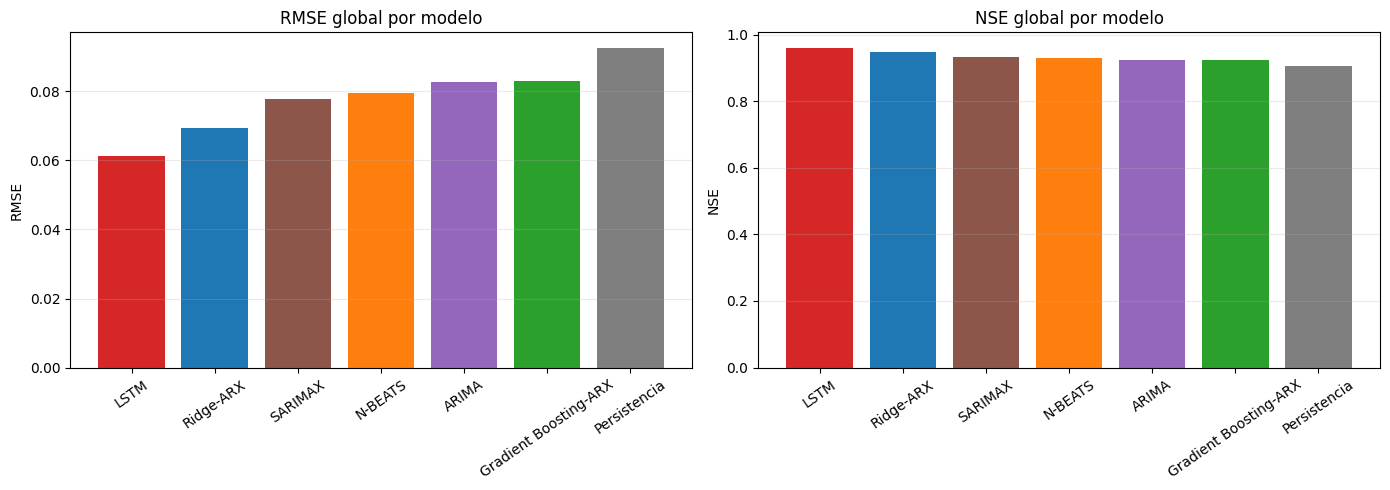

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_rmse_por_horizonte_global.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_rmse_por_horizonte_global.pdf


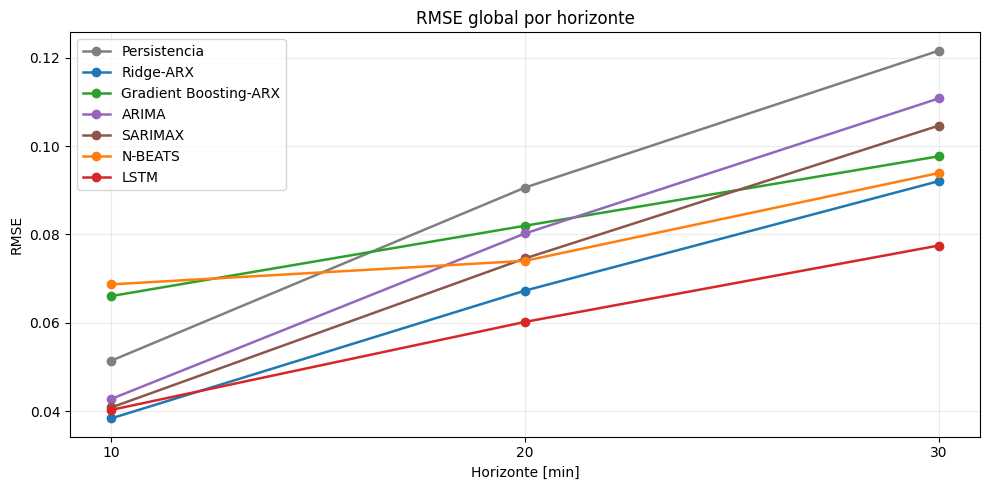

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_heatmap_rmse_condiciones_t30.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_heatmap_rmse_condiciones_t30.pdf


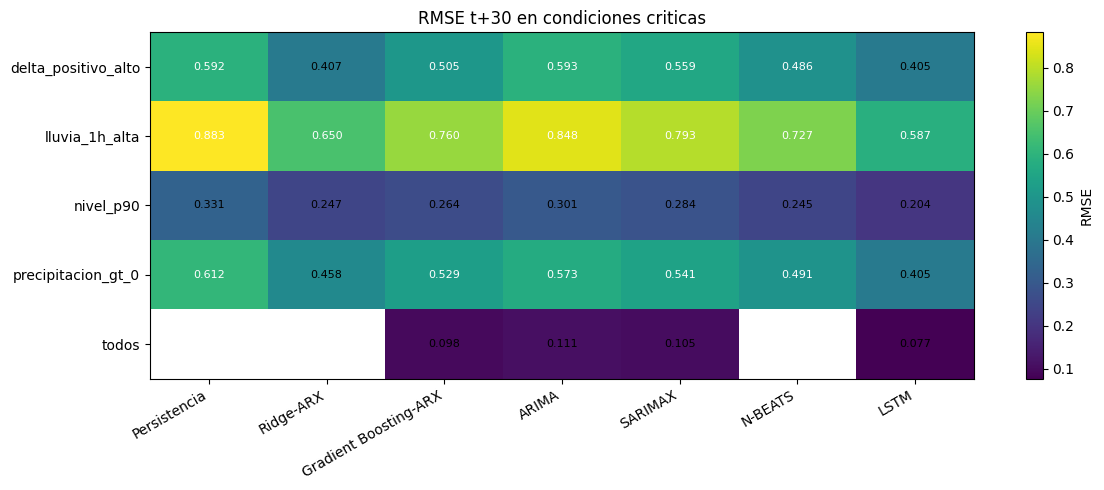

In [21]:
def save_figure(fig, filename):
    png_path = os.path.join(FIGURES_DIR, filename + ".png")
    pdf_path = os.path.join(FIGURES_DIR, filename + ".pdf")
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Guardado:", png_path)
    print("Guardado:", pdf_path)


plot_df = global_only_df.sort_values("RMSE").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(plot_df["modelo_label"], plot_df["RMSE"], color=[MODEL_COLORS.get(m, "tab:blue") for m in plot_df["modelo"]])
axes[0].set_title("RMSE global por modelo")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.25)

plot_nse = global_only_df.sort_values("NSE", ascending=False).copy()
axes[1].bar(plot_nse["modelo_label"], plot_nse["NSE"], color=[MODEL_COLORS.get(m, "tab:green") for m in plot_nse["modelo"]])
axes[1].set_title("NSE global por modelo")
axes[1].set_ylabel("NSE")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
save_figure(fig, "24_metricas_globales_rmse_nse")
plt.show()


plot_df = metrics_lead_df[metrics_lead_df["segmento"] == "global"].copy()
fig, ax = plt.subplots(figsize=(10, 5))

for model_name in MODEL_ORDER:
    model_df = plot_df[plot_df["modelo"] == model_name].sort_values("lead_minutes")
    if model_df.empty:
        continue
    ax.plot(
        model_df["lead_minutes"],
        model_df["RMSE"],
        marker="o",
        linewidth=1.8,
        label=MODEL_LABELS.get(model_name, model_name),
        color=MODEL_COLORS.get(model_name),
    )

ax.set_title("RMSE global por horizonte")
ax.set_xlabel("Horizonte [min]")
ax.set_ylabel("RMSE")
ax.set_xticks([10, 20, 30])
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
save_figure(fig, "24_rmse_por_horizonte_global")
plt.show()


heatmap_data = pivot_rmse_conditions_t30_df.copy()
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("RMSE t+30 en condiciones criticas")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value > np.nanmean(heatmap_data.values) else "black", fontsize=8)

fig.colorbar(im, ax=ax, label="RMSE")
fig.tight_layout()
save_figure(fig, "24_heatmap_rmse_condiciones_t30")
plt.show()

## Carga de predicciones para figuras de evento

In [22]:
def read_prediction_csv(path, model_name=None):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    for col in ["origin_time", "pred_time"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    df["segmento"] = df["segmento"].astype(str)
    if model_name is not None:
        df["modelo"] = model_name
    df["modelo"] = df["modelo"].astype(str)
    return df


def load_export_predictions(model_name, file_label):
    frames = []
    for segment_name in ["2021", "2025"]:
        path = os.path.join(PRED_EXPORT_DIR, f"predicciones_test_{segment_name}_{file_label}.csv")
        df = read_prediction_csv(path, model_name=model_name)
        if df is not None:
            frames.append(df)
    if frames:
        return pd.concat(frames, axis=0, ignore_index=True)
    return None


def build_persistence_predictions_from_export():
    frames = []
    for segment_name in ["2021", "2025"]:
        path = os.path.join(PRED_EXPORT_DIR, f"train_val_test_{segment_name}.csv")
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
        df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).set_index(TIME_COL)
        df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").interpolate(method="time").ffill().bfill()
        df[RAIN_COL] = pd.to_numeric(df[RAIN_COL], errors="coerce").fillna(0.0)
        df["lluvia_1h"] = df[RAIN_COL].rolling(6, min_periods=1).sum()
        df["delta_nivel"] = df[TARGET_COL].diff()

        if "split" not in df.columns:
            continue

        test_positions = np.flatnonzero(df["split"].astype(str).str.lower().eq("test").values)
        if len(test_positions) == 0:
            continue

        values = df[TARGET_COL].values.astype(float)
        time_index = df.index
        first_origin = int(test_positions[0])
        last_origin = len(df) - FORECAST_HORIZON

        rows = []
        for origin in range(first_origin, last_origin + 1):
            origin_time = time_index[origin - 1]
            forecast = np.repeat(values[origin - 1], FORECAST_HORIZON)

            for lead_step in range(1, FORECAST_HORIZON + 1):
                pred_index = origin + lead_step - 1
                pred_time = time_index[pred_index]
                rows.append({
                    "segmento": segment_name,
                    "modelo": "Persistencia",
                    "origin_time": origin_time,
                    "pred_time": pred_time,
                    "lead_step": lead_step,
                    "lead_minutes": lead_step * 10,
                    "actual": float(values[pred_index]),
                    "pred": float(forecast[lead_step - 1]),
                    RAIN_COL: float(df.iloc[pred_index][RAIN_COL]),
                    "lluvia_1h": float(df.iloc[pred_index]["lluvia_1h"]),
                    "delta_nivel": float(df.iloc[pred_index]["delta_nivel"]) if pd.notna(df.iloc[pred_index]["delta_nivel"]) else np.nan,
                })

        frames.append(pd.DataFrame(rows))

    if frames:
        return pd.concat(frames, axis=0, ignore_index=True)
    return None


prediction_sources = {
    "Persistencia": build_persistence_predictions_from_export(),
    "Ridge_ARX_local": load_export_predictions("Ridge_ARX_local", "ridge_arx"),
    "NBEATS": load_export_predictions("NBEATS", "nbeats"),
    "GradientBoosting_ARX": read_prediction_csv(os.path.join(REPORTS_ROOT, "23_gradient_boosting_arx", "23_predicciones_test_long.csv")),
    "ARIMA_SARIMAX": read_prediction_csv(os.path.join(REPORTS_ROOT, "17_arima_sarimax_baselines", "17_predicciones_test_long.csv")),
    "LSTM": read_prediction_csv(os.path.join(REPORTS_ROOT, "22_lstm_vs_modelos", "22_predicciones_test_long.csv")),
}

prediction_frames = []
missing_prediction_sources = []

for source_name, df in prediction_sources.items():
    if df is None or df.empty:
        missing_prediction_sources.append(source_name)
        continue
    prediction_frames.append(df)

predictions_long_df = pd.concat(prediction_frames, axis=0, ignore_index=True)
predictions_long_df["segmento"] = predictions_long_df["segmento"].astype(str)
predictions_long_df["modelo"] = predictions_long_df["modelo"].astype(str)
predictions_long_df["modelo_label"] = predictions_long_df["modelo"].map(MODEL_LABELS).fillna(predictions_long_df["modelo"])
predictions_long_df["model_order"] = predictions_long_df["modelo"].map({model: idx for idx, model in enumerate(MODEL_ORDER)})
predictions_long_df = predictions_long_df[predictions_long_df["modelo"].isin(MODEL_ORDER)].copy()

predictions_path = save_table(predictions_long_df, "24_predicciones_test_long_modelos_disponibles.csv")

missing_predictions_df = pd.DataFrame({"fuente_predicciones_faltante": missing_prediction_sources})
if len(missing_predictions_df):
    save_table(missing_predictions_df, "24_predicciones_fuentes_faltantes.csv")
    display(missing_predictions_df)

display(predictions_long_df.head())
display(predictions_long_df.groupby(["modelo", "segmento", "lead_minutes"]).size().reset_index(name="n").head(30))

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_predicciones_test_long_modelos_disponibles.csv


,segmento,modelo,origin_time,pred_time,lead_step,lead_minutes,actual,pred,Precipitacion,lluvia_1h,delta_nivel,modelo_label,model_order
0,2021,Persistencia,2022-02-16 17:00:00,2022-02-16 17:10:00,1,10,0.092288,0.091673,0.0,0.0,0.000615,Persistencia,0
1,2021,Persistencia,2022-02-16 17:00:00,2022-02-16 17:20:00,2,20,0.090951,0.091673,0.0,0.0,-0.001337,Persistencia,0
2,2021,Persistencia,2022-02-16 17:00:00,2022-02-16 17:30:00,3,30,0.089209,0.091673,0.0,0.0,-0.001742,Persistencia,0
3,2021,Persistencia,2022-02-16 17:10:00,2022-02-16 17:20:00,1,10,0.090951,0.092288,0.0,0.0,-0.001337,Persistencia,0
4,2021,Persistencia,2022-02-16 17:10:00,2022-02-16 17:30:00,2,20,0.089209,0.092288,0.0,0.0,-0.001742,Persistencia,0


,modelo,segmento,lead_minutes,n
0,ARIMA_selected,2021,10,6331
1,ARIMA_selected,2021,20,6331
2,ARIMA_selected,2021,30,6331
3,ARIMA_selected,2025,10,4357
4,ARIMA_selected,2025,20,4357
5,ARIMA_selected,2025,30,4357
6,GradientBoosting_ARX,2021,10,6331
7,GradientBoosting_ARX,2021,20,6331
8,GradientBoosting_ARX,2021,30,6331
9,GradientBoosting_ARX,2025,10,4357


## Seleccion de evento para figura temporal

In [23]:
event_candidates = predictions_long_df[
    (predictions_long_df["segmento"] == EVENT_SEGMENT)
    & (predictions_long_df["lead_minutes"] == LEAD_TO_PLOT)
].copy()

if event_candidates.empty:
    raise RuntimeError("No hay predicciones disponibles para seleccionar el evento.")

reference_model_for_event = "Ridge_ARX_local" if "Ridge_ARX_local" in set(event_candidates["modelo"]) else event_candidates["modelo"].iloc[0]
event_reference = event_candidates[event_candidates["modelo"] == reference_model_for_event].copy()

if EVENT_SELECTION == "max_lluvia_1h" and "lluvia_1h" in event_reference.columns:
    event_row = event_reference.loc[event_reference["lluvia_1h"].idxmax()]
else:
    event_row = event_reference.loc[event_reference["actual"].idxmax()]

event_time = pd.Timestamp(event_row["pred_time"])
start_time = event_time - pd.Timedelta(hours=ZOOM_HOURS_BEFORE)
end_time = event_time + pd.Timedelta(hours=ZOOM_HOURS_AFTER)

event_metadata_df = pd.DataFrame([{
    "segmento": EVENT_SEGMENT,
    "lead_minutes": LEAD_TO_PLOT,
    "event_selection": EVENT_SELECTION,
    "reference_model_for_event": reference_model_for_event,
    "event_time": event_time,
    "start_time": start_time,
    "end_time": end_time,
    "actual_at_event": float(event_row["actual"]),
    "lluvia_1h_at_event": float(event_row["lluvia_1h"]) if "lluvia_1h" in event_row else np.nan,
}])

save_table(event_metadata_df, "24_evento_seleccionado.csv")
display(event_metadata_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_evento_seleccionado.csv


,segmento,lead_minutes,event_selection,reference_model_for_event,event_time,start_time,end_time,actual_at_event,lluvia_1h_at_event
0,2025,30,max_actual,Ridge_ARX_local,2026-03-16 16:00:00,2026-03-16 10:00:00,2026-03-17 04:00:00,3.3,13.0


## Figura de evento: curvas de prediccion a t+30

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_evento_2025_predicciones_t30_todos_modelos_disponibles.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_evento_2025_predicciones_t30_todos_modelos_disponibles.pdf


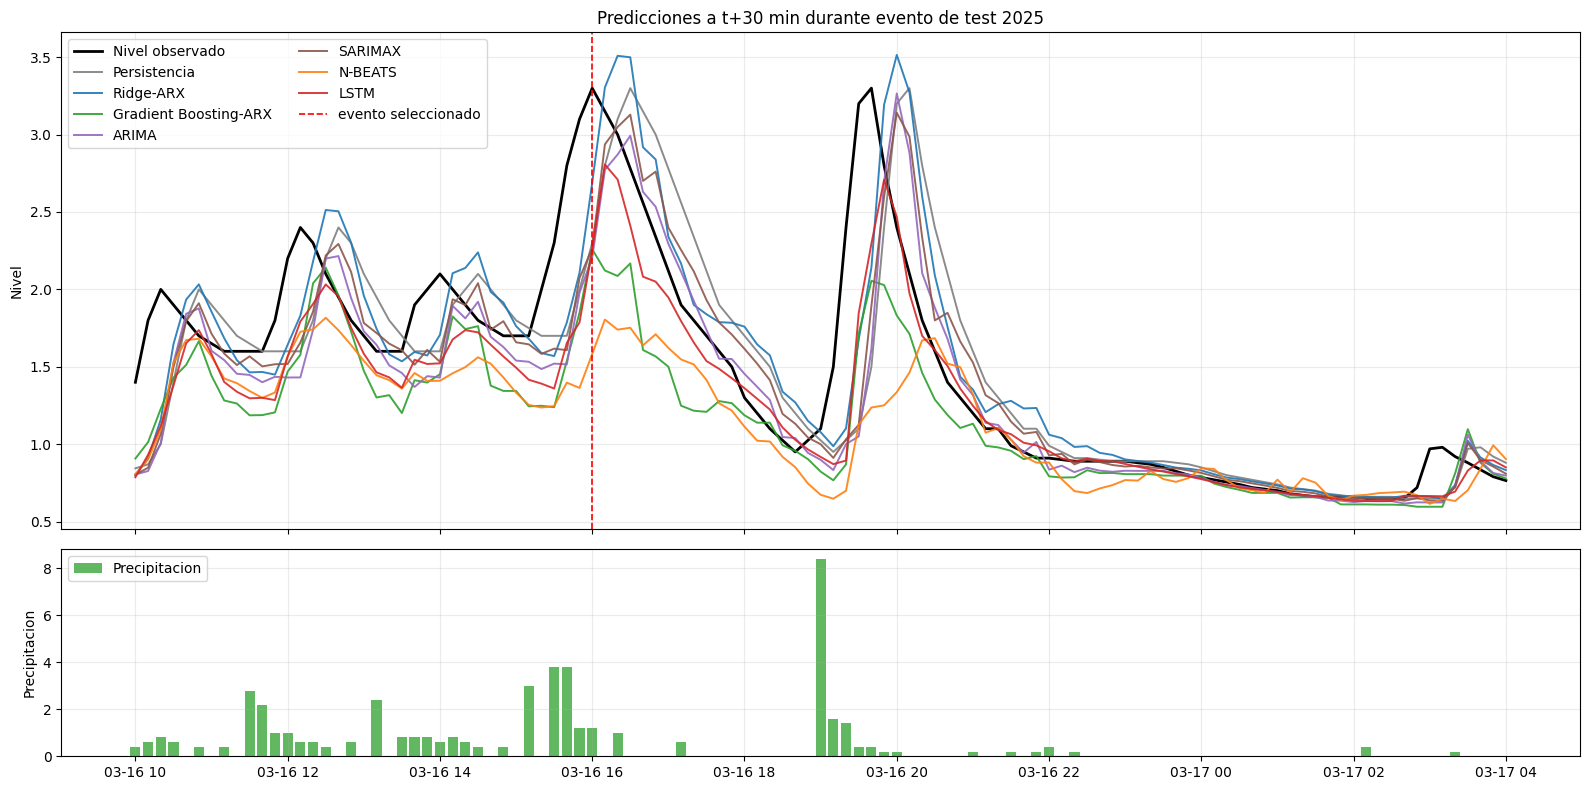

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_evento_2025_predicciones_t30_long.csv


In [24]:
event_plot_df = predictions_long_df[
    (predictions_long_df["segmento"] == EVENT_SEGMENT)
    & (predictions_long_df["lead_minutes"] == LEAD_TO_PLOT)
    & (predictions_long_df["pred_time"] >= start_time)
    & (predictions_long_df["pred_time"] <= end_time)
].copy()

if event_plot_df.empty:
    raise RuntimeError("No hay datos para graficar el evento seleccionado.")

actual_reference = (
    event_plot_df
    .sort_values(["pred_time", "model_order"])
    .drop_duplicates("pred_time")
    .sort_values("pred_time")
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1]},
)

axes[0].plot(
    actual_reference["pred_time"],
    actual_reference["actual"],
    color="black",
    linewidth=2.0,
    label="Nivel observado",
)

for model_name in MODEL_ORDER:
    model_df = event_plot_df[event_plot_df["modelo"] == model_name].sort_values("pred_time")
    if model_df.empty:
        continue
    axes[0].plot(
        model_df["pred_time"],
        model_df["pred"],
        linewidth=1.4,
        alpha=0.9,
        label=MODEL_LABELS.get(model_name, model_name),
        color=MODEL_COLORS.get(model_name),
    )

axes[0].axvline(event_time, color="red", linestyle="--", linewidth=1.2, label="evento seleccionado")
axes[0].set_title(f"Predicciones a t+{LEAD_TO_PLOT} min durante evento de test {EVENT_SEGMENT}")
axes[0].set_ylabel("Nivel")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left", ncol=2)

bar_width_days = 8 / (24 * 60)
axes[1].bar(
    actual_reference["pred_time"],
    actual_reference[RAIN_COL],
    width=bar_width_days,
    color="tab:green",
    alpha=0.75,
    label="Precipitacion",
)
axes[1].set_ylabel("Precipitacion")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper left")

fig.tight_layout()
save_figure(fig, f"24_evento_{EVENT_SEGMENT}_predicciones_t{LEAD_TO_PLOT}_todos_modelos_disponibles")
plt.show()

event_plot_path = save_table(event_plot_df, f"24_evento_{EVENT_SEGMENT}_predicciones_t{LEAD_TO_PLOT}_long.csv")

## Evaluacion hidrologica basada en eventos: tiempo y magnitud del pico

Las metricas globales punto a punto, como RMSE, MAE, NSE o R2, son necesarias para comparar el desempeno promedio de los modelos. Sin embargo, en pronostico hidrologico de crecidas tambien interesa saber si el modelo reproduce correctamente el **momento del pico** y la **magnitud del pico**.

Esta distincion es importante porque dos modelos pueden tener errores globales parecidos, pero fallar de maneras hidrologicamente distintas:

- un modelo puede acertar el tiempo del pico, pero subestimar mucho la altura;
- otro modelo puede reproducir una amplitud razonable, pero con retraso temporal;
- otro puede suavizar toda la crecida y obtener errores moderados en periodos tranquilos.

La literatura hidrologica advierte que las metricas estandar no separan explicitamente errores de tiempo y errores de amplitud. Seibert, Ehret y Zehe (2016) proponen analizar por separado los errores de **timing** y **amplitude** en simulaciones de caudal. En aplicaciones recientes de pronostico de crecidas con aprendizaje profundo tambien se reportan metricas especificas de eventos, como el error en el tiempo al pico y el error relativo del pico.

Referencias metodologicas:

- Seibert, J., Ehret, U. y Zehe, E. (2016). *Disentangling timing and amplitude errors in streamflow simulations*. Hydrology and Earth System Sciences, 20, 3745-3763. https://doi.org/10.5194/hess-20-3745-2016
- Frame, J. M., Kratzert, F., Klotz, D., Gauch, M., Shalev, G., Gilon, O., Qualls, L., Gupta, H. V. y Nearing, G. S. (2022). *Deep learning rainfall-runoff predictions of extreme events*. Hydrology and Earth System Sciences, 26, 3377-3392. https://doi.org/10.5194/hess-26-3377-2022
- Song, T., Ding, W., Wu, J., Liu, H., Zhou, H. y Chu, J. (2020). *Flash Flood Forecasting Based on Long Short-Term Memory Networks*. Water, 12(1), 109. https://doi.org/10.3390/w12010109

En este notebook se agregan metricas de pico para complementar las tablas globales. No sustituyen a RMSE/MAE/NSE; las hacen mas interpretables para eventos criticos.

## Definicion de las nuevas metricas de pico

Para cada evento, modelo y horizonte de prediccion se identifica:

- `t_peak_obs`: instante del maximo nivel observado dentro de la ventana del evento.
- `t_peak_pred`: instante del maximo nivel predicho por el modelo dentro de la misma ventana.
- `peak_obs`: maximo nivel observado.
- `peak_pred`: maximo nivel predicho.

Con esos valores se calculan las siguientes metricas:

**Peak Time Error, `PTE_min`**

```text
PTE_min = t_peak_pred - t_peak_obs
```

Se expresa en minutos. Si es positivo, el modelo predijo el pico tarde. Si es negativo, lo predijo antes del observado. Su valor absoluto, `abs_PTE_min`, mide el error temporal sin importar la direccion.

**Error de magnitud del pico, `peak_error`**

```text
peak_error = peak_pred - peak_obs
```

Si es negativo, el modelo subestima el pico. Si es positivo, lo sobreestima. Tambien se calcula `abs_peak_error` y el error relativo porcentual:

```text
rel_peak_error_pct = 100 * (peak_pred - peak_obs) / peak_obs
```

**Error en el instante del pico observado, `error_at_obs_peak`**

```text
error_at_obs_peak = prediccion(t_peak_obs) - observado(t_peak_obs)
```

Esta metrica responde una pregunta operacional concreta: cuanto se equivoca el modelo justo en el momento en que ocurre el maximo observado?

**Metricas dentro de ventana de evento**

Tambien se calculan RMSE, MAE, sesgo y NSE dentro de cada ventana. Estas metricas resumen la forma completa de la crecida local, mientras que `PTE_min` y `peak_error` resumen especificamente tiempo y magnitud del pico.

## Seleccion automatica de eventos para metricas de pico

Para evitar que la evaluacion dependa de un unico evento elegido visualmente, se construye un catalogo automatico de picos observados en test.

La seleccion usa solo el nivel observado, no las predicciones, para no favorecer a ningun modelo. Dentro de cada segmento se buscan maximos locales de nivel, se retienen los eventos por encima del percentil configurado y se impone una separacion temporal minima entre eventos. Luego, cada evento se evalua con la misma ventana temporal para todos los modelos y todos los horizontes.

Esta estrategia permite generar dos tipos de tablas:

- una tabla detallada por evento, modelo y horizonte;
- una tabla resumen por modelo y horizonte, util para el paper.

In [42]:
EVENT_PEAK_LEVEL_QUANTILE = 0.90
EVENT_PEAKS_PER_SEGMENT = 5
EVENT_MIN_SEPARATION_HOURS = 6
EVENT_WINDOW_BEFORE_HOURS = 2
EVENT_WINDOW_AFTER_HOURS = 2


def build_observed_series_for_events(predictions_df):
    observed_cols = ["segmento", "pred_time", "actual"]
    for optional_col in [RAIN_COL, "lluvia_1h", "delta_nivel"]:
        if optional_col in predictions_df.columns:
            observed_cols.append(optional_col)

    observed_df = (
        predictions_df[observed_cols]
        .dropna(subset=["segmento", "pred_time", "actual"])
        .sort_values(["segmento", "pred_time"])
        .drop_duplicates(["segmento", "pred_time"])
        .reset_index(drop=True)
    )
    return observed_df


def select_peak_events_for_segment(observed_segment_df, segment_name):
    segment_df = observed_segment_df.sort_values("pred_time").reset_index(drop=True).copy()
    if segment_df.empty:
        return pd.DataFrame()

    values = segment_df["actual"].to_numpy(dtype=float)
    local_peak_positions = []
    for i, value in enumerate(values):
        left = values[i - 1] if i > 0 else -np.inf
        right = values[i + 1] if i < len(values) - 1 else -np.inf
        if value >= left and value >= right:
            local_peak_positions.append(i)

    if not local_peak_positions:
        local_peak_positions = [int(np.nanargmax(values))]

    candidates_df = segment_df.iloc[local_peak_positions].copy()
    level_threshold = segment_df["actual"].quantile(EVENT_PEAK_LEVEL_QUANTILE)
    high_candidates_df = candidates_df[candidates_df["actual"] >= level_threshold].copy()
    if high_candidates_df.empty:
        high_candidates_df = candidates_df.copy()

    high_candidates_df = (
        high_candidates_df
        .sort_values(["actual", "pred_time"], ascending=[False, True])
        .reset_index(drop=True)
    )

    selected_rows = []
    min_sep = pd.Timedelta(hours=EVENT_MIN_SEPARATION_HOURS)

    for _, candidate in high_candidates_df.iterrows():
        candidate_time = pd.Timestamp(candidate["pred_time"])
        too_close = any(abs(candidate_time - pd.Timestamp(row["t_peak_obs"])) < min_sep for row in selected_rows)
        if too_close:
            continue

        selected_rows.append({
            "event_id": f"{segment_name}_E{len(selected_rows) + 1:02d}",
            "segmento": segment_name,
            "selection_rank": len(selected_rows) + 1,
            "t_peak_obs": candidate_time,
            "peak_obs": float(candidate["actual"]),
            "precip_at_peak": float(candidate[RAIN_COL]) if RAIN_COL in candidate.index and pd.notna(candidate[RAIN_COL]) else np.nan,
            "lluvia_1h_at_peak": float(candidate["lluvia_1h"]) if "lluvia_1h" in candidate.index and pd.notna(candidate["lluvia_1h"]) else np.nan,
            "start_time": candidate_time - pd.Timedelta(hours=EVENT_WINDOW_BEFORE_HOURS),
            "end_time": candidate_time + pd.Timedelta(hours=EVENT_WINDOW_AFTER_HOURS),
            "level_quantile_threshold": float(level_threshold),
        })

        if len(selected_rows) >= EVENT_PEAKS_PER_SEGMENT:
            break

    return pd.DataFrame(selected_rows)


observed_events_base_df = build_observed_series_for_events(predictions_long_df)

event_catalog_frames = []
for segment_name, observed_segment_df in observed_events_base_df.groupby("segmento"):
    event_catalog_frames.append(select_peak_events_for_segment(observed_segment_df, segment_name))

event_catalog_df = pd.concat(event_catalog_frames, axis=0, ignore_index=True)
event_catalog_df = event_catalog_df.sort_values(["segmento", "selection_rank"]).reset_index(drop=True)

save_table(event_catalog_df, "24_eventos_catalogo_picos.csv")
display(event_catalog_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_eventos_catalogo_picos.csv


,event_id,segmento,selection_rank,t_peak_obs,peak_obs,precip_at_peak,lluvia_1h_at_peak,start_time,end_time,level_quantile_threshold
0,2021_E01,2021,1,2022-03-23 10:00:00,3.746000,1.2,48.6,2022-03-23 08:00:00,2022-03-23 12:00:00,0.325751
1,2021_E02,2021,2,2022-03-22 18:50:00,3.705000,0.6,56.6,2022-03-22 16:50:00,2022-03-22 20:50:00,0.325751
2,2021_E03,2021,3,2022-03-10 22:00:00,2.520960,0.8,31.4,2022-03-10 20:00:00,2022-03-11 00:00:00,0.325751
3,2021_E04,2021,4,2022-03-18 17:50:00,1.505000,0.0,14.6,2022-03-18 15:50:00,2022-03-18 19:50:00,0.325751
4,2021_E05,2021,5,2022-02-21 16:00:00,1.179999,0.0,7.4,2022-02-21 14:00:00,2022-02-21 18:00:00,0.325751
5,2025_E01,2025,1,2026-03-16 16:00:00,3.300000,1.2,13.0,2026-03-16 14:00:00,2026-03-16 18:00:00,0.570000
6,2025_E02,2025,2,2026-03-03 16:10:00,2.600000,0.0,10.6,2026-03-03 14:10:00,2026-03-03 18:10:00,0.570000
7,2025_E03,2025,3,2026-02-24 17:50:00,2.300000,0.2,9.4,2026-02-24 15:50:00,2026-02-24 19:50:00,0.570000
8,2025_E04,2025,4,2026-03-08 18:50:00,2.200000,0.0,22.4,2026-03-08 16:50:00,2026-03-08 20:50:00,0.570000
9,2025_E05,2025,5,2026-02-23 17:40:00,1.900000,0.0,0.6,2026-02-23 15:40:00,2026-02-23 19:40:00,0.570000


## Calculo de metricas de pico por evento, modelo y horizonte

En esta celda se evalua cada modelo dentro de la ventana local de cada evento. El maximo observado se calcula a partir de la serie observada en esa ventana, y el maximo predicho se calcula a partir de las predicciones del modelo en la misma ventana y horizonte.

El signo de `PTE_min` se conserva porque tiene interpretacion fisica:

- `PTE_min > 0`: prediccion tardia del pico;
- `PTE_min < 0`: prediccion anticipada del pico;
- `PTE_min = 0`: el pico predicho coincide temporalmente con el pico observado.

Para comparar modelos de manera agregada se usa tambien `abs_PTE_min`, porque resume la magnitud del error temporal independientemente de la direccion.

In [43]:
def nse_score_event(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    if denominator <= 0:
        return np.nan
    return 1.0 - np.sum((y_true - y_pred) ** 2) / denominator


def closest_prediction_at_time(model_event_df, target_time):
    exact = model_event_df[model_event_df["pred_time"] == target_time]
    if not exact.empty:
        row = exact.iloc[0]
        return float(row["pred"]), 0.0

    time_deltas = (model_event_df["pred_time"] - target_time).abs()
    closest_idx = time_deltas.idxmin()
    row = model_event_df.loc[closest_idx]
    delta_minutes = (pd.Timestamp(row["pred_time"]) - target_time).total_seconds() / 60.0
    return float(row["pred"]), float(delta_minutes)


event_metric_rows = []
available_leads = sorted(predictions_long_df["lead_minutes"].dropna().unique())

for _, event in event_catalog_df.iterrows():
    segment_name = str(event["segmento"])
    start = pd.Timestamp(event["start_time"])
    end = pd.Timestamp(event["end_time"])

    observed_window_df = observed_events_base_df[
        (observed_events_base_df["segmento"] == segment_name)
        & (observed_events_base_df["pred_time"] >= start)
        & (observed_events_base_df["pred_time"] <= end)
    ].copy()

    if observed_window_df.empty:
        continue

    obs_peak_row = observed_window_df.loc[observed_window_df["actual"].idxmax()]
    t_peak_obs = pd.Timestamp(obs_peak_row["pred_time"])
    peak_obs = float(obs_peak_row["actual"])

    for lead_minutes in available_leads:
        lead_event_df = predictions_long_df[
            (predictions_long_df["segmento"] == segment_name)
            & (predictions_long_df["lead_minutes"] == lead_minutes)
            & (predictions_long_df["pred_time"] >= start)
            & (predictions_long_df["pred_time"] <= end)
        ].copy()

        if lead_event_df.empty:
            continue

        for model_name, model_event_df in lead_event_df.groupby("modelo"):
            model_event_df = model_event_df.sort_values("pred_time").dropna(subset=["actual", "pred"]).copy()
            if len(model_event_df) < 3:
                continue

            pred_peak_row = model_event_df.loc[model_event_df["pred"].idxmax()]
            t_peak_pred = pd.Timestamp(pred_peak_row["pred_time"])
            peak_pred = float(pred_peak_row["pred"])

            pred_at_obs_peak, obs_peak_prediction_time_offset_min = closest_prediction_at_time(
                model_event_df,
                t_peak_obs,
            )

            errors = model_event_df["pred"].to_numpy(dtype=float) - model_event_df["actual"].to_numpy(dtype=float)
            rmse_event = float(np.sqrt(np.mean(errors ** 2)))
            mae_event = float(np.mean(np.abs(errors)))
            bias_event = float(np.mean(errors))
            nse_event = float(nse_score_event(model_event_df["actual"], model_event_df["pred"]))

            pte_min = (t_peak_pred - t_peak_obs).total_seconds() / 60.0
            peak_error = peak_pred - peak_obs
            rel_peak_error_pct = 100.0 * peak_error / peak_obs if peak_obs != 0 else np.nan
            error_at_obs_peak = pred_at_obs_peak - peak_obs

            event_metric_rows.append({
                "event_id": event["event_id"],
                "segmento": segment_name,
                "selection_rank": int(event["selection_rank"]),
                "lead_minutes": int(lead_minutes),
                "modelo": model_name,
                "modelo_label": MODEL_LABELS.get(model_name, model_name),
                "model_family": MODEL_FAMILIES.get(model_name, "Otro"),
                "model_order": MODEL_ORDER.index(model_name) if model_name in MODEL_ORDER else 999,
                "window_start": start,
                "window_end": end,
                "t_peak_obs": t_peak_obs,
                "t_peak_pred": t_peak_pred,
                "PTE_min": pte_min,
                "abs_PTE_min": abs(pte_min),
                "peak_obs": peak_obs,
                "peak_pred": peak_pred,
                "peak_error": peak_error,
                "abs_peak_error": abs(peak_error),
                "rel_peak_error_pct": rel_peak_error_pct,
                "abs_rel_peak_error_pct": abs(rel_peak_error_pct) if pd.notna(rel_peak_error_pct) else np.nan,
                "pred_at_obs_peak": pred_at_obs_peak,
                "obs_peak_prediction_time_offset_min": obs_peak_prediction_time_offset_min,
                "error_at_obs_peak": error_at_obs_peak,
                "abs_error_at_obs_peak": abs(error_at_obs_peak),
                "RMSE_evento": rmse_event,
                "MAE_evento": mae_event,
                "Bias_evento": bias_event,
                "NSE_evento": nse_event,
                "n_puntos_evento": int(len(model_event_df)),
            })

event_peak_metrics_df = pd.DataFrame(event_metric_rows)

if event_peak_metrics_df.empty:
    raise RuntimeError("No se pudieron calcular metricas de pico. Revise el catalogo de eventos y las predicciones.")

event_peak_metrics_df = event_peak_metrics_df.sort_values([
    "lead_minutes",
    "segmento",
    "selection_rank",
    "model_order",
]).reset_index(drop=True)

save_table(event_peak_metrics_df, "24_metricas_eventos_pico_detalle.csv")

display_cols = [
    "event_id",
    "lead_minutes",
    "modelo",
    "t_peak_obs",
    "t_peak_pred",
    "PTE_min",
    "peak_obs",
    "peak_pred",
    "peak_error",
    "RMSE_evento",
    "MAE_evento",
]
display(event_peak_metrics_df[event_peak_metrics_df["lead_minutes"] == LEAD_TO_PLOT][display_cols].head(30))

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_eventos_pico_detalle.csv


,event_id,lead_minutes,modelo,t_peak_obs,t_peak_pred,PTE_min,peak_obs,peak_pred,peak_error,RMSE_evento,MAE_evento
140,2021_E01,30,Persistencia,2022-03-23 10:00:00,2022-03-23 10:30:00,30.0,3.746000,3.746000,0.000000,1.076933,0.865560
141,2021_E01,30,Ridge_ARX_local,2022-03-23 10:00:00,2022-03-23 10:10:00,10.0,3.746000,5.439671,1.693671,0.896228,0.720307
142,2021_E01,30,GradientBoosting_ARX,2022-03-23 10:00:00,2022-03-23 10:30:00,30.0,3.746000,2.035190,-1.710810,0.902662,0.604353
143,2021_E01,30,ARIMA_selected,2022-03-23 10:00:00,2022-03-23 10:20:00,20.0,3.746000,3.349555,-0.396445,0.973042,0.702333
144,2021_E01,30,SARIMAX_lagged_exog_selected,2022-03-23 10:00:00,2022-03-23 10:20:00,20.0,3.746000,3.721660,-0.024340,0.928039,0.677611
145,2021_E01,30,NBEATS,2022-03-23 10:00:00,2022-03-23 10:00:00,0.0,3.746000,3.123155,-0.622845,0.607198,0.442077
146,2021_E01,30,LSTM,2022-03-23 10:00:00,2022-03-23 10:00:00,0.0,3.746000,4.235288,0.489288,0.633069,0.447368
147,2021_E02,30,Persistencia,2022-03-22 18:50:00,2022-03-22 19:20:00,30.0,3.705000,3.705000,0.000000,1.192636,0.774680
148,2021_E02,30,Ridge_ARX_local,2022-03-22 18:50:00,2022-03-22 19:00:00,10.0,3.705000,5.178025,1.473025,0.705220,0.491357
149,2021_E02,30,GradientBoosting_ARX,2022-03-22 18:50:00,2022-03-22 19:00:00,10.0,3.705000,1.938283,-1.766717,0.969898,0.594432


## Tablas resumen de metricas de eventos

Las tablas resumen agregan las metricas por modelo y horizonte. Para el analisis del paper, las columnas mas utiles son:

- `mean_abs_PTE_min`: error temporal absoluto medio del pico. Valores menores indican mejor ubicacion temporal del maximo.
- `mean_signed_PTE_min`: sesgo temporal medio. Valores positivos indican tendencia a predecir tarde; valores negativos indican tendencia a anticipar.
- `mean_abs_peak_error`: error absoluto medio de magnitud del pico.
- `mean_peak_error`: sesgo medio de magnitud. Valores negativos indican subestimacion sistematica del pico.
- `mean_abs_error_at_obs_peak`: error medio justo en el instante del pico observado.
- `mean_RMSE_evento` y `mean_MAE_evento`: error promedio dentro de las ventanas locales de crecida.

Esta separacion permite distinguir modelos que fallan por fase temporal de modelos que fallan por amplitud.

In [44]:
event_peak_summary_by_lead_df = (
    event_peak_metrics_df
    .groupby(["modelo", "modelo_label", "model_family", "model_order", "lead_minutes"], dropna=False)
    .agg(
        n_eventos=("event_id", "nunique"),
        mean_signed_PTE_min=("PTE_min", "mean"),
        median_signed_PTE_min=("PTE_min", "median"),
        mean_abs_PTE_min=("abs_PTE_min", "mean"),
        median_abs_PTE_min=("abs_PTE_min", "median"),
        mean_peak_error=("peak_error", "mean"),
        mean_abs_peak_error=("abs_peak_error", "mean"),
        mean_rel_peak_error_pct=("rel_peak_error_pct", "mean"),
        mean_abs_rel_peak_error_pct=("abs_rel_peak_error_pct", "mean"),
        mean_error_at_obs_peak=("error_at_obs_peak", "mean"),
        mean_abs_error_at_obs_peak=("abs_error_at_obs_peak", "mean"),
        mean_RMSE_evento=("RMSE_evento", "mean"),
        mean_MAE_evento=("MAE_evento", "mean"),
        mean_Bias_evento=("Bias_evento", "mean"),
        mean_NSE_evento=("NSE_evento", "mean"),
    )
    .reset_index()
    .sort_values(["lead_minutes", "mean_RMSE_evento", "model_order"])
    .reset_index(drop=True)
)

event_peak_summary_global_df = (
    event_peak_metrics_df
    .groupby(["modelo", "modelo_label", "model_family", "model_order"], dropna=False)
    .agg(
        n_eventos_modelo_horizonte=("event_id", "count"),
        n_eventos_unicos=("event_id", "nunique"),
        mean_signed_PTE_min=("PTE_min", "mean"),
        median_signed_PTE_min=("PTE_min", "median"),
        mean_abs_PTE_min=("abs_PTE_min", "mean"),
        median_abs_PTE_min=("abs_PTE_min", "median"),
        mean_peak_error=("peak_error", "mean"),
        mean_abs_peak_error=("abs_peak_error", "mean"),
        mean_rel_peak_error_pct=("rel_peak_error_pct", "mean"),
        mean_abs_rel_peak_error_pct=("abs_rel_peak_error_pct", "mean"),
        mean_error_at_obs_peak=("error_at_obs_peak", "mean"),
        mean_abs_error_at_obs_peak=("abs_error_at_obs_peak", "mean"),
        mean_RMSE_evento=("RMSE_evento", "mean"),
        mean_MAE_evento=("MAE_evento", "mean"),
        mean_Bias_evento=("Bias_evento", "mean"),
        mean_NSE_evento=("NSE_evento", "mean"),
    )
    .reset_index()
    .sort_values(["mean_RMSE_evento", "model_order"])
    .reset_index(drop=True)
)

event_peak_t30_summary_df = event_peak_summary_by_lead_df[
    event_peak_summary_by_lead_df["lead_minutes"] == LEAD_TO_PLOT
].copy().sort_values(["mean_RMSE_evento", "model_order"]).reset_index(drop=True)

save_table(event_peak_summary_by_lead_df, "24_metricas_eventos_pico_resumen_por_lead.csv")
save_table(event_peak_summary_global_df, "24_metricas_eventos_pico_resumen_global.csv")
save_table(event_peak_t30_summary_df, f"24_metricas_eventos_pico_resumen_t{LEAD_TO_PLOT}.csv")

display(event_peak_t30_summary_df)
display(event_peak_summary_global_df)

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_eventos_pico_resumen_por_lead.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_eventos_pico_resumen_global.csv
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\24_metricas_eventos_pico_resumen_t30.csv


,modelo,modelo_label,model_family,model_order,lead_minutes,n_eventos,mean_signed_PTE_min,median_signed_PTE_min,mean_abs_PTE_min,median_abs_PTE_min,mean_peak_error,mean_abs_peak_error,mean_rel_peak_error_pct,mean_abs_rel_peak_error_pct,mean_error_at_obs_peak,mean_abs_error_at_obs_peak,mean_RMSE_evento,mean_MAE_evento,mean_Bias_evento,mean_NSE_evento
0,LSTM,LSTM,Deep learning recurrente,6,30,10,12.0,10.0,14.0,10.0,0.142673,0.376718,4.802027,14.630751,-0.247624,0.738270,0.381353,0.230580,-0.087610,0.583894
1,NBEATS,N-BEATS,Deep learning,5,30,10,5.0,0.0,7.0,5.0,-0.223937,0.480859,-4.996588,18.923480,-0.453824,0.702682,0.428294,0.255186,-0.140389,0.403892
2,Ridge_ARX_local,Ridge-ARX,ML lineal ARX,1,30,10,19.0,20.0,21.0,20.0,0.502247,0.503420,16.862802,16.962179,-0.265943,0.758381,0.457537,0.312160,0.031449,0.439455
3,GradientBoosting_ARX,Gradient Boosting-ARX,ML no lineal ARX,2,30,10,16.0,20.0,20.0,20.0,-0.790155,0.854804,-26.488953,31.967669,-1.101749,1.130868,0.494627,0.305322,-0.229278,0.375097
4,SARIMAX_lagged_exog_selected,SARIMAX,Estadistico con exogenas,4,30,10,26.0,30.0,26.0,30.0,0.001135,0.117318,0.141006,5.527676,-1.205826,1.205826,0.554245,0.345270,-0.096397,0.219435
5,ARIMA_selected,ARIMA,Estadistico,3,30,10,25.0,30.0,25.0,30.0,0.071934,0.262825,5.303170,11.604558,-1.271703,1.271703,0.591144,0.345755,-0.133946,0.098366
6,Persistencia,Persistencia,Baseline ingenuo,0,30,10,30.0,30.0,30.0,30.0,0.000000,0.000000,0.000000,0.000000,-1.360759,1.360759,0.649420,0.442955,-0.029367,-0.055661


,modelo,modelo_label,model_family,model_order,n_eventos_modelo_horizonte,n_eventos_unicos,mean_signed_PTE_min,median_signed_PTE_min,mean_abs_PTE_min,median_abs_PTE_min,mean_peak_error,mean_abs_peak_error,mean_rel_peak_error_pct,mean_abs_rel_peak_error_pct,mean_error_at_obs_peak,mean_abs_error_at_obs_peak,mean_RMSE_evento,mean_MAE_evento,mean_Bias_evento,mean_NSE_evento
0,LSTM,LSTM,Deep learning recurrente,6,30,10,6.333333,10.0,11.666667,10.0,0.077716,0.205757,2.856331,7.991131,-0.333858,0.531658,0.294314,0.172419,-0.049166,0.730047
1,Ridge_ARX_local,Ridge-ARX,ML lineal ARX,1,30,10,13.000000,10.0,14.333333,10.0,0.427325,0.434028,15.526746,16.094773,-0.231231,0.642736,0.336198,0.216233,0.028098,0.644115
2,NBEATS,N-BEATS,Deep learning,5,30,10,4.000000,5.0,7.333333,10.0,0.094816,0.424884,4.219434,15.792719,-0.210009,0.567068,0.342824,0.202930,-0.030539,0.611712
3,SARIMAX_lagged_exog_selected,SARIMAX,Estadistico con exogenas,4,30,10,16.000000,20.0,16.000000,20.0,0.055333,0.126870,2.384293,5.902943,-0.739464,0.785005,0.390420,0.228997,-0.062095,0.542587
4,GradientBoosting_ARX,Gradient Boosting-ARX,ML no lineal ARX,2,30,10,8.333333,10.0,13.666667,10.0,-0.634942,0.702900,-19.535056,25.109306,-0.949011,0.972614,0.414619,0.247282,-0.176427,0.546096
5,ARIMA_selected,ARIMA,Estadistico,3,30,10,16.000000,20.0,16.000000,20.0,0.135005,0.238826,7.624280,10.947053,-0.794981,0.828383,0.417596,0.227173,-0.082280,0.472086
6,Persistencia,Persistencia,Baseline ingenuo,0,30,10,20.000000,20.0,20.000000,20.0,0.000000,0.000000,0.000000,0.000000,-0.916941,0.916941,0.471232,0.304773,-0.017562,0.373643


## Graficos diagnosticos de error temporal y error de magnitud

Los graficos siguientes no buscan reemplazar la figura de curvas. Su funcion es resumir la discusion:

- un modelo cerca del origen en el grafico de dispersion tiene bajo error temporal y bajo error de magnitud;
- un modelo desplazado hacia la derecha tiene mayor error temporal del pico;
- un modelo alto en el eje vertical tiene mayor error de magnitud del pico.

Esta visualizacion permite argumentar si un modelo mejora por anticipar mejor los picos, por reproducir mejor su altura, o por ambas cosas.

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_eventos_pico_barras_t30.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_eventos_pico_barras_t30.pdf


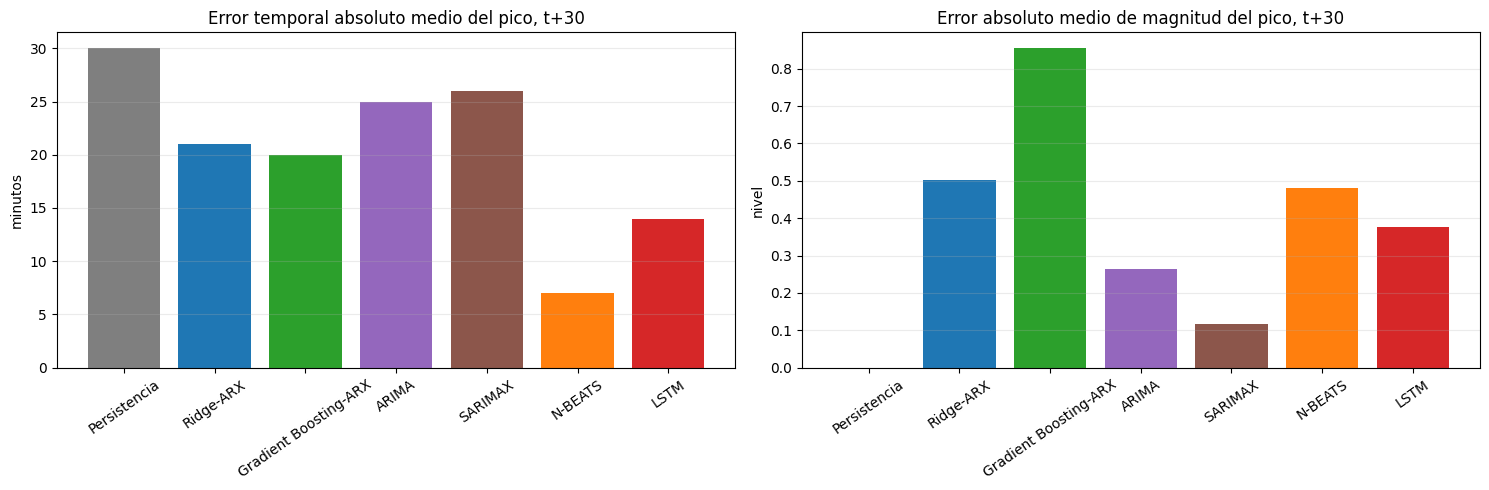

Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_eventos_pico_tradeoff_t30.png
Guardado: g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\reports\24_comparaciones_Iberamia\figures\24_eventos_pico_tradeoff_t30.pdf


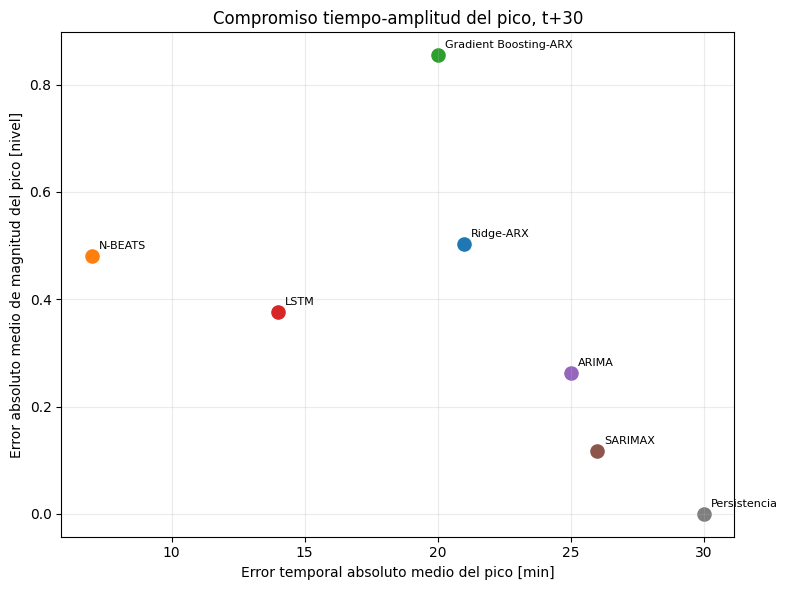

: 

In [ ]:
if event_peak_t30_summary_df.empty:
    raise RuntimeError(f"No hay resumen de eventos para lead t+{LEAD_TO_PLOT}.")

plot_df = event_peak_t30_summary_df.sort_values("model_order").copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(
    plot_df["modelo_label"],
    plot_df["mean_abs_PTE_min"],
    color=[MODEL_COLORS.get(model, "tab:gray") for model in plot_df["modelo"]],
)
axes[0].set_title(f"Error temporal absoluto medio del pico, t+{LEAD_TO_PLOT}")
axes[0].set_ylabel("minutos")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    plot_df["modelo_label"],
    plot_df["mean_abs_peak_error"],
    color=[MODEL_COLORS.get(model, "tab:gray") for model in plot_df["modelo"]],
)
axes[1].set_title(f"Error absoluto medio de magnitud del pico, t+{LEAD_TO_PLOT}")
axes[1].set_ylabel("nivel")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
save_figure(fig, f"24_eventos_pico_barras_t{LEAD_TO_PLOT}")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["mean_abs_PTE_min"],
        row["mean_abs_peak_error"],
        s=90,
        color=MODEL_COLORS.get(row["modelo"], "tab:gray"),
        label=row["modelo_label"],
    )
    ax.annotate(
        row["modelo_label"],
        (row["mean_abs_PTE_min"], row["mean_abs_peak_error"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"Compromiso tiempo-amplitud del pico, t+{LEAD_TO_PLOT}")
ax.set_xlabel("Error temporal absoluto medio del pico [min]")
ax.set_ylabel("Error absoluto medio de magnitud del pico [nivel]")
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, f"24_eventos_pico_tradeoff_t{LEAD_TO_PLOT}")
plt.show()

## Salidas generadas

In [29]:
generated_files = []
for root, _, files in os.walk(REPORTS_DIR):
    for filename in files:
        generated_files.append(os.path.join(root, filename))

generated_files_df = pd.DataFrame({"archivo": sorted(generated_files)})
display(generated_files_df)

,archivo
0,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
1,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
2,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
3,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
4,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
5,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
6,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
7,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
8,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
9,g:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mbu...
